In [3]:
# Import required libraries
import pandas as pd
import numpy as np
# For visualization
import seaborn as sns
import matplotlib.pyplot as plt
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load dataset
data = pd.read_csv("Machine Learning Model Implementation – Spam Email Detection/spam.csv", encoding='latin-1')

# Show first 5 rows
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Keep only required columns
data = data[['v1','v2']]

# Rename columns
data.columns = ['label','message']

# Convert label to numeric
data['label'] = data['label'].map({'ham':0, 'spam':1})

# Display dataset info
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# Features and labels
X = data['message']
y = data['label']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Convert text to numbers using CountVectorizer
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
# Create model
model = MultinomialNB()

# Train model
model.fit(X_train_vec, y_train)

MultinomialNB()

In [9]:
# Predict on test data
y_pred = model.predict(X_test_vec)

In [10]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.9838565022421525
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



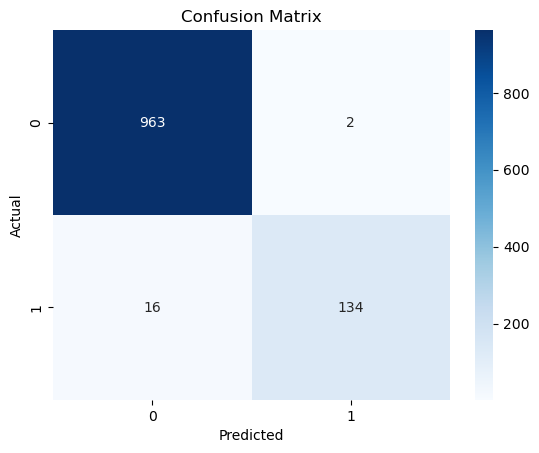

In [11]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
# Test with new email
sample = ["Congratulations! You have won a free lottery ticket"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Spam Email
